# VibrationAnalyzer demo - Accelerometer Transducer Sweep Data


This demo analysis will demonstrate how to use the `VibrationAnalyzer` class in detanalysis to analyze transducer sweep datasets.

The VibrationAnalyzer class contains special functions for calculating and visualizing differential **transfer functions** between accelerometer channels using various estimator methods ('rms-ratio', 'cross-correlation', 'phase-locked').

Acquire the raw accelerometer transducer sweep data by running `pytesdaq/bin/run_transducer_sweep.py` with the daq recording an accelerometer channel.
Make sure the signal generator is plugged into the transducer, and the TTL of the signal generator is connected to the DAQ TTL input.

### Overall workflow:

Process raw data -> Initialize `VibrationAnalyzer(data_type='transducer_sweep')` -> `calc_psd()` -> `calc_transfer_function()`

---
## Processing

Before running this notebook, you must first perform processing on the raw transducer sweep data. This is very easy.

Simply run the following command in a terminal, replacing `<raw_data_dir>` with the path to your raw transducer sweep data group directory, and `<detprocess>` with the path to your detprocess package:

```bash
python <detprocess>/scripts/process_transducer_sweep.py --raw_path <raw_data_dir>
```

For example (cd'd into my detprocess/scripts directory):
```bash
python process_transducer_sweep.py --raw_path /sdata1/runs/run73/raw/transducer_sweep_I2_D20260624_T110933
```

---
## Setup

In [1]:
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import pickle

from detanalysis import Vibration_Analyzer

## Parameters

In [ ]:
# ================================================
#               Processed data path
# ================================================

processed_data_path = (
    "/sdata1/runs/run73/processed/transducer_sweep_I2_D20260621_T095242"
)



# ================================================
#              Channel configuration
# ================================================

channels = ['AccelerometerGround', 'AccelerometerStage1', 'AccelerometerStage2']

# Channel pairs for transfer functions: [output, input]
tf_channel_pairs = [
    ['AccelerometerStage1', 'AccelerometerGround'],   # Stage1 / Ground
    ['AccelerometerStage2', 'AccelerometerStage1'],    # Stage2 / Stage1
    ['AccelerometerStage2', 'AccelerometerGround'],    # Stage2 / Ground
]

---
## Load Processed Data

In [3]:
analyzer = Vibration_Analyzer(processed_data_path, data_type='transducer_sweep')
analyzer.describe()
analyzer.df

Number of files: 1
Number of events: 7131
Number of features: 18
Is DataFrame filtered? False
No cuts have been registered!
No derived features have been added!


#,channel_names,frequency_hz,signal_gen_voltage,trace_index,file_name,sample_rate_hz,trace_length_msec,accel_gain,amp_real_AccelerometerGround,amp_imag_AccelerometerGround,amp_complex_AccelerometerGround,amp_real_AccelerometerStage1,amp_imag_AccelerometerStage1,amp_complex_AccelerometerStage1,amp_real_AccelerometerStage2,amp_imag_AccelerometerStage2,amp_complex_AccelerometerStage2,index
0,"'AccelerometerGround,AccelerometerStage1,Acceler...",10.0,2.0,0,transducer_sweep_I2_D20260621_T095259_F0001.hdf5,500000.0,15000.0,100.0,-2.359628260269459e-06,-1.6305601558031428e-06,-2.359628260269459e-06+-1.6305601558031428e-06j,2.6970561070560746e-07,2.0192925352590404e-07,2.6970561070560746e-07+2.0192925352590404e-07j,-7.389112753649941e-08,-4.859221139369727e-09,-7.389112753649941e-08+-4.859221139369727e-09j,0
1,"'AccelerometerGround,AccelerometerStage1,Acceler...",10.0,2.0,1,transducer_sweep_I2_D20260621_T095259_F0001.hdf5,500000.0,15000.0,100.0,-3.42737038561676e-06,-1.931284294475572e-06,-3.42737038561676e-06+-1.931284294475572e-06j,3.7279805014774576e-07,2.0840735447588125e-07,3.7279805014774576e-07+2.0840735447588125e-07j,-7.48235208025294e-08,-1.945738128322874e-08,-7.48235208025294e-08+-1.945738128322874e-08j,1
2,"'AccelerometerGround,AccelerometerStage1,Acceler...",10.0,2.0,2,transducer_sweep_I2_D20260621_T095259_F0001.hdf5,500000.0,15000.0,100.0,-2.7039821355290614e-06,-1.4239915611100426e-07,-2.7039821355290614e-06+-1.4239915611100426e-07j,2.242388117929072e-07,7.215329199416231e-08,2.242388117929072e-07+7.215329199416231e-08j,-5.205841818240471e-08,-1.564465686931817e-08,-5.205841818240471e-08+-1.564465686931817e-08j,2
3,"'AccelerometerGround,AccelerometerStage1,Acceler...",10.0,2.0,3,transducer_sweep_I2_D20260621_T095259_F0001.hdf5,500000.0,15000.0,100.0,-2.4593680423406407e-06,-2.2557373197167117e-06,-2.4593680423406407e-06+-2.2557373197167117e-06j,2.927294209540602e-07,2.433028056533932e-07,2.927294209540602e-07+2.433028056533932e-07j,-4.039121438650079e-08,-3.859153582370553e-09,-4.039121438650079e-08+-3.859153582370553e-09j,3
4,"'AccelerometerGround,AccelerometerStage1,Acceler...",10.0,2.0,4,transducer_sweep_I2_D20260621_T095259_F0001.hdf5,500000.0,15000.0,100.0,-2.8094108886208894e-06,-1.7520379908578649e-06,-2.8094108886208894e-06+-1.7520379908578649e-06j,2.799732926077035e-07,1.7224598311669267e-07,2.799732926077035e-07+1.7224598311669267e-07j,-4.729325050578634e-08,2.6415561678969258e-08,-4.729325050578634e-08+2.6415561678969258e-08j,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"7,126","'AccelerometerGround,AccelerometerStage1,Acceler...",2000.0,2.0,3,transducer_sweep_I2_D20260622_T212154_F0001.hdf5,500000.0,15000.0,100.0,0.00021207950278267847,0.0006422526441323536,0.00021207950278267847+0.0006422526441323536j,-3.0671509733601224e-06,-1.1841525065769447e-05,-3.0671509733601224e-06+-1.1841525065769447e-05j,8.500934940221313e-07,-3.999742192416107e-06,8.500934940221313e-07+-3.999742192416107e-06j,7126
"7,127","'AccelerometerGround,AccelerometerStage1,Acceler...",2000.0,2.0,4,transducer_sweep_I2_D20260622_T212154_F0001.hdf5,500000.0,15000.0,100.0,0.0002131830945484225,0.0006416618634317551,0.0002131830945484225+0.0006416618634317551j,-3.120110451298078e-06,-1.184888916284413e-05,-3.120110451298078e-06+-1.184888916284413e-05j,8.579104007173647e-07,-3.998401984182785e-06,8.579104007173647e-07+-3.998401984182785e-06j,7127
"7,128","'AccelerometerGround,AccelerometerStage1,Acceler...",2000.0,2.0,5,transducer_sweep_I2_D20260622_T212154_F0001.hdf5,500000.0,15000.0,100.0,0.00021228518604084345,0.0006413455576126094,0.00021228518604084345+0.0006413455576126094j,-3.0908579551835478e-06,-1.1841101233595744e-05,-3.0908579551835478e-06+-1.1841101233595744e-05j,8.459548757305016e-07,-3.9950747712911914e-06,8.459548757305016e-07+-3.9950747712911914e-06j,7128
"7,129","'AccelerometerGround,AccelerometerStage1,Acceler...",2000.0,2.0,6,transducer_sweep_I2_D20260622_T212154_F0001.hdf5,500000.0,15000.0,100.

---
## PSDs

In [4]:
# ================================================
#              Calculate PSDs
# ================================================

psd, variance, freqs = analyzer.calc_psd(
    channels=channels
)

Text(0.5, 1.0, 'RMS Acceleration')

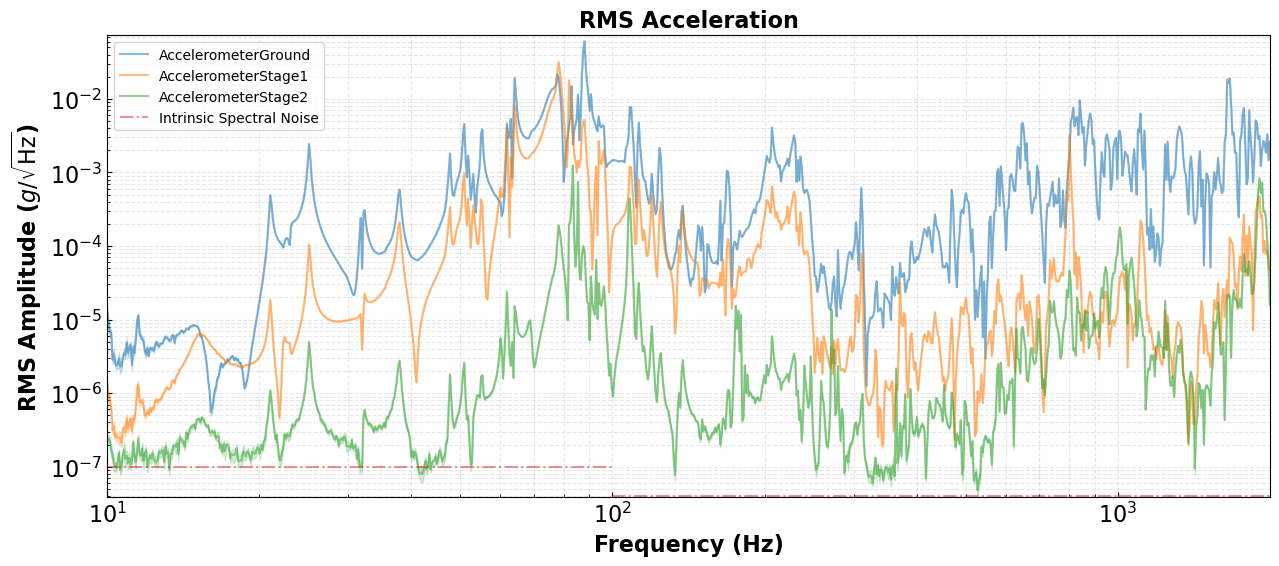

In [5]:
# ================================================
#               Plot PSDs
# ================================================

# Here is the special VibrationAnalyzer plot_psd() function.
# Feel free to use your own plotting with lists `psd` and `freqs` if desired.
fig, ax = analyzer.plot_psd(channels=channels, figsize=(15,6))

ax.set_title("RMS Acceleration", fontsize=16, fontweight='bold')

---
## Transfer Function

Vibration Analyzer supports multiple transfer function estimator methods.

You can specify `methods = 'rms-ratio'`, `methods = 'cross-correlation'`, or `methods = 'phase-locked'` (only for transducer sweeps) to plot a single estimator, or `methods = ['rms-ratio', 'phase-locked']` (or `methods = 'all'`) to overlay multiple estimators on the same plot.

It also supports plotting multiple channel pairs at the same time.

For extremeley large datasets, use log_downsample=True to reduce the number of points plotted visually.

In [6]:
# ================================================
#          Calculate Transfer Functions
# ================================================
tf_results = analyzer.calc_transfer_function(
    channel_pairs=[ # defines which differential transfer functions to calculate
        ['AccelerometerStage1', 'AccelerometerGround'],    # Stage1 / Ground
        ['AccelerometerStage2', 'AccelerometerStage1'],    # Stage2 / Stage1
        ['AccelerometerStage2', 'AccelerometerGround'],    # Stage2 / Ground
    ],
    methods=['rms-ratio', 'cross-correlation', 'phase-locked'], # 'rms-ratio', 'cross-correlation', 'phase-locked', 'all' strings are accepted, or list of multiple
)

print(tf_results.keys())

dict_keys(['rms-ratio', 'cross-correlation', 'phase-locked'])


(7.6727049901092546, 1700)

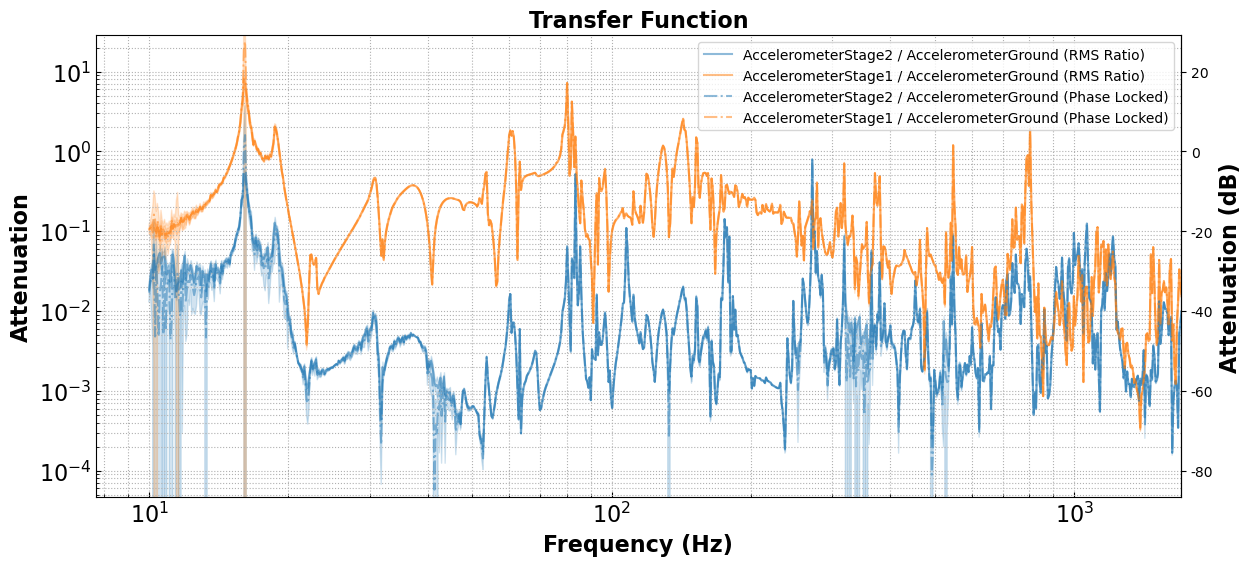

In [9]:
# ================================================
#             Plot Transfer Functions
# ================================================
# MUST first call calc_transfer_function()
# This will cache the results in the object for plotting.

fig, ax = analyzer.plot_transfer_function(
    channel_pairs=[ # defines which differential transfer functions to plot
        ['AccelerometerStage2', 'AccelerometerGround'],     # Stage2 / Ground
        ['AccelerometerStage1', 'AccelerometerGround']      # Stage1 / Ground
    ],
    methods=['rms-ratio', 'phase-locked'],  # 'rms-ratio', 'cross-correlation', 'phase-locked', 'all' strings are accepted, or list of multiple methods
    log_downsample=True, # Use if getting errors about dataset size too large
)
ax.set_title('Transfer Function', fontsize=16, fontweight='bold')
ax.set_xlim(right=1700)